In [9]:
#Logistic Regression model

#cell 1 - imports

import pandas as pd
import numpy as np
import gzip
import json
import urllib.request
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings("ignore")
 

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.utils import resample
from wordcloud import WordCloud
 
nltk.download("punkt",        quiet=True)
nltk.download("stopwords",    quiet=True)
nltk.download("wordnet",      quiet=True)
nltk.download("punkt_tab",    quiet=True)
 
print("All libraries loaded successfully!")
print(f"Scikit-learn is ready for Logistic Regression.")

All libraries loaded successfully!
Scikit-learn is ready for Logistic Regression.


In [10]:
#cell 2

url       = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz"
file_name = "All_Beauty.jsonl.gz"
 
print("Downloading dataset (this may take a moment)...")
urllib.request.urlretrieve(url, file_name)
print("Download complete.")
 
print("Streaming JSONL.GZ file into a balanced dataset...")
 
TARGET_PER_CLASS = 50_000   #50k positive + 50k negative = 100k total
chunk_size       = 10_000
 
pos_list, neg_list = [], []
 
with gzip.open(file_name, "rt", encoding="utf-8") as f:
    chunk = []
    for i, line in enumerate(f):
        chunk.append(json.loads(line))
        if len(chunk) == chunk_size:
            cdf     = pd.DataFrame(chunk)[["text", "rating"]].dropna()
            pos_list.append(cdf[cdf["rating"] >= 4])
            neg_list.append(cdf[cdf["rating"] <= 2])
            chunk = []
            cur_pos = sum(len(c) for c in pos_list)
            cur_neg = sum(len(c) for c in neg_list)
            print(f"  Collected: {cur_pos:,} Pos | {cur_neg:,} Neg ...", end="\r")
            if cur_pos >= TARGET_PER_CLASS and cur_neg >= TARGET_PER_CLASS:
                print("\n  Target reached! Stopping stream.")
                break
 
df_pos = pd.concat(pos_list).iloc[:TARGET_PER_CLASS]
df_neg = pd.concat(neg_list).iloc[:TARGET_PER_CLASS]
 
df = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)
df["label"] = df["rating"].apply(lambda x: 1 if x >= 4 else 0)
 
#3 star reviews that were naturally excluded
with gzip.open(file_name, "rt", encoding="utf-8") as f:
    neutral_count = sum(1 for line in f if json.loads(line).get("rating") == 3.0)
 
print(f"\nDataset loaded!")
print(f"  3-star (neutral) reviews excluded : {neutral_count:,}")
print(f"  Positive reviews (4-5 stars)      : {len(df_pos):,}")
print(f"  Negative reviews (1-2 stars)      : {len(df_neg):,}")
print(f"  Total balanced dataset            : {len(df):,}")
df.head(3)
 

Download complete.
Streaming JSONL.GZ file into a balanced dataset...
  Collected: 205,153 Pos | 50,289 Neg ...
  Target reached! Stopping stream.

Dataset loaded!
  3-star (neutral) reviews excluded : 56,307
  Positive reviews (4-5 stars)      : 50,000
  Negative reviews (1-2 stars)      : 50,000
  Total balanced dataset            : 100,000


,text,rating,label
0,It wasnt a lot of money but its enuf to be mad...,1.0,0
1,Didn’t like the 2 shapes,1.0,0
2,I suffer from having hard skin around the heel...,4.0,1


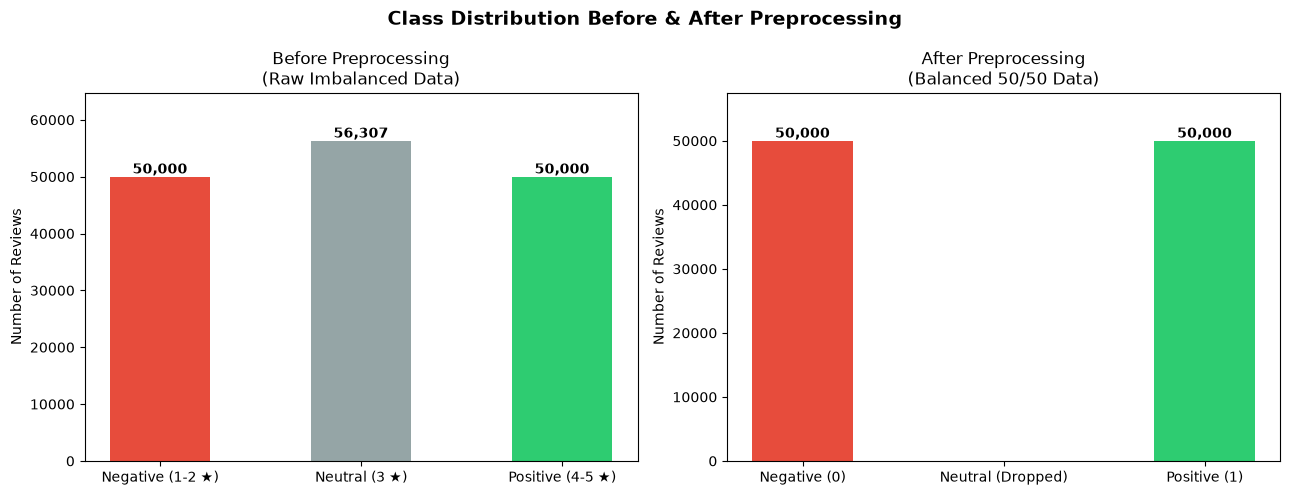

In [11]:
# cell 3 - Raw counts (approximate from what we streamed)
raw_pos = len(df_pos)
raw_neg = len(df_neg)
raw_neu = neutral_count
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Class Distribution Before & After Preprocessing", fontsize=14, fontweight="bold")
 
cats_before  = ["Negative (1-2 ★)", "Neutral (3 ★)", "Positive (4-5 ★)"]
cnts_before  = [raw_neg, raw_neu, raw_pos]
bars0 = axes[0].bar(cats_before, cnts_before, color=["#e74c3c", "#95a5a6", "#2ecc71"], width=0.5)
axes[0].set_title("Before Preprocessing\n(Raw Imbalanced Data)", fontsize=12)
axes[0].set_ylabel("Number of Reviews")
axes[0].set_ylim(0, max(cnts_before) * 1.15)
for bar, val in zip(bars0, cnts_before):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(cnts_before) * 0.01,
                 f"{val:,}", ha="center", fontweight="bold", fontsize=10)

cats_after = ["Negative (0)", "Neutral (Dropped)", "Positive (1)"]
cnts_after = [len(df[df["label"] == 0]), 0, len(df[df["label"] == 1])]
bars1 = axes[1].bar(cats_after, cnts_after, color=["#e74c3c", "#95a5a6", "#2ecc71"], width=0.5)
axes[1].set_title("After Preprocessing\n(Balanced 50/50 Data)", fontsize=12)
axes[1].set_ylabel("Number of Reviews")
axes[1].set_ylim(0, max(cnts_after) * 1.15)
for bar, val in zip(bars1, cnts_after):
    if val > 0:
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(cnts_after) * 0.01,
                     f"{val:,}", ha="center", fontweight="bold", fontsize=10)
 
plt.tight_layout()
plt.show()
 

In [12]:
#cell 4 - Preprocessing

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words("english"))
 
def preprocess_for_logreg(text: str) -> str:
    """
    Full preprocessing pipeline tailored for TF-IDF + Logistic Regression.
 
    Steps
    -----
    1. Lowercase
    2. Remove URLs, HTML tags, punctuation, digits
    3. Tokenize
    4. Remove stopwords  (important: reduces TF-IDF noise)
    5. Lemmatize         (collapses word forms → smaller, cleaner vocab)
    6. Remove very short tokens (< 3 chars)
 
    Returns
    -------
    str : cleaned text ready for TfidfVectorizer
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+",    " ", text)   # URLs
    text = re.sub(r"<[^>]+>",           " ", text)   # HTML tags
    text = re.sub(r"[^a-z\s]",          " ", text)   # non-alpha
    text = re.sub(r"\s+",               " ", text).strip()
 
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) >= 3]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
 
    return " ".join(tokens)
 
 
print("Applying preprocessing pipeline to all reviews...")
print("(Lowercase → Remove noise → Tokenize → Stopwords → Lemmatize)\n")
 
df["text_clean"] = df["text"].apply(preprocess_for_logreg)
 
print("BEFORE → AFTER examples:")
print("─" * 70)
for i in [0, 1, 2]:
    print(f"[RAW]   {df['text'].iloc[i][:120]}")
    print(f"[CLEAN] {df['text_clean'].iloc[i][:120]}")
    print()
 

Applying preprocessing pipeline to all reviews...
(Lowercase → Remove noise → Tokenize → Stopwords → Lemmatize)

BEFORE → AFTER examples:
──────────────────────────────────────────────────────────────────────
[RAW]   It wasnt a lot of money but its enuf to be mad that they split the hair that should be on one extention and made it into
[CLEAN] wasnt lot money enuf mad split hair one extention made happy enuf wanted like said barely enuf one piece soft color grea

[RAW]   Didn’t like the 2 shapes
[CLEAN] like shape

[RAW]   I suffer from having hard skin around the heel and bottom area of my foot.  It gets real hard and I have to soften it up
[CLEAN] suffer hard skin around heel bottom area foot get real hard soften hot water epson salt use stone scrub away skin harden



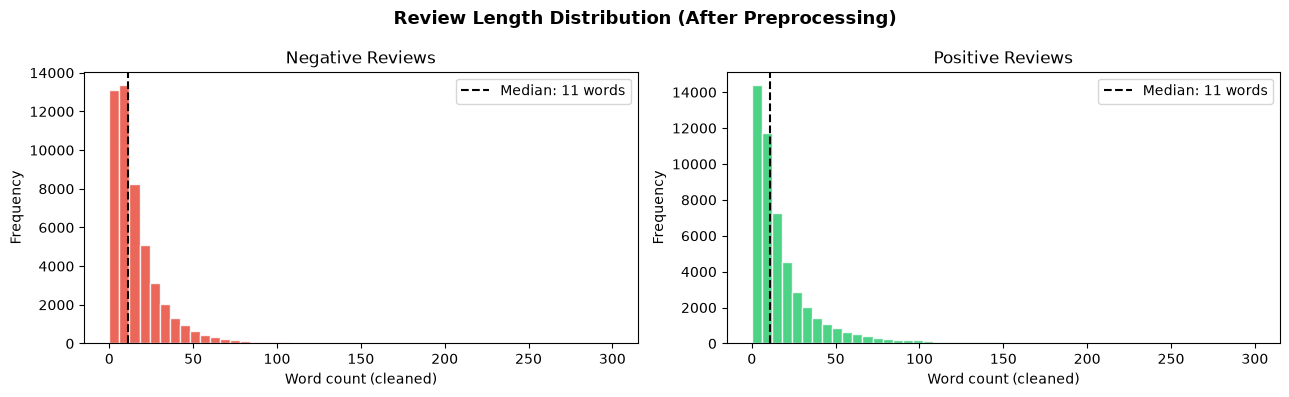

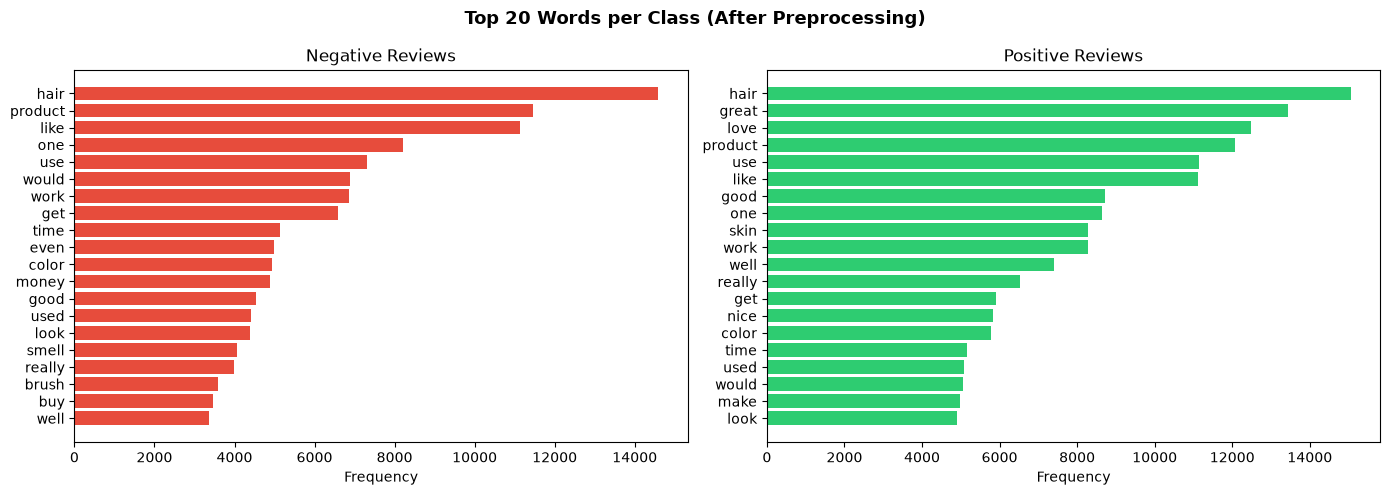

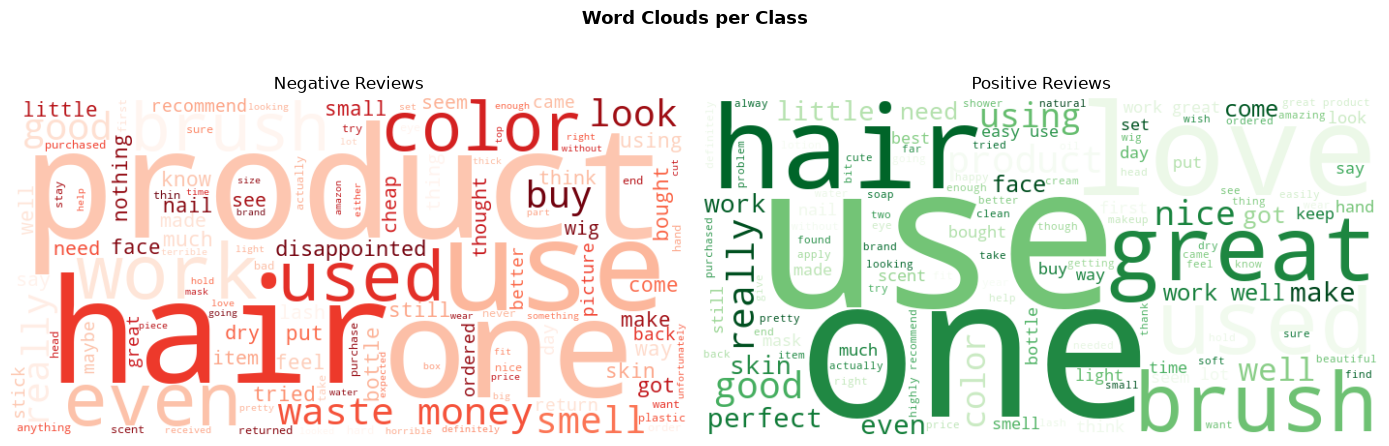

In [13]:
#cell 5 

df["length_raw"]   = df["text"].str.split().str.len()
df["length_clean"] = df["text_clean"].str.split().str.len()
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Review Length Distribution (After Preprocessing)", fontsize=13, fontweight="bold")
 
for ax, (label, name, color) in zip(axes, [(0, "Negative", "#e74c3c"), (1, "Positive", "#2ecc71")]):
    subset = df[df["label"] == label]["length_clean"].clip(upper=300)
    ax.hist(subset, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(subset.median(), color="black", linestyle="--", linewidth=1.5,
               label=f"Median: {subset.median():.0f} words")
    ax.set_title(f"{name} Reviews")
    ax.set_xlabel("Word count (cleaned)")
    ax.set_ylabel("Frequency")
    ax.legend()
 
plt.tight_layout()
plt.show()

from collections import Counter
 
def top_words(texts, n=20):
    words = [w for t in texts for w in t.split() if len(w) >= 3]
    return Counter(words).most_common(n)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top 20 Words per Class (After Preprocessing)", fontsize=13, fontweight="bold")
 
for ax, (label, name, color) in zip(axes, [(0, "Negative", "#e74c3c"), (1, "Positive", "#2ecc71")]):
    pairs = top_words(df[df["label"] == label]["text_clean"])
    words, freqs = zip(*pairs)
    ax.barh(list(words)[::-1], list(freqs)[::-1], color=color)
    ax.set_title(f"{name} Reviews")
    ax.set_xlabel("Frequency")
 
plt.tight_layout()
plt.show()
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Word Clouds per Class", fontsize=13, fontweight="bold")
 
for ax, (label, name, cmap) in zip(axes, [(0, "Negative", "Reds"), (1, "Positive", "Greens")]):
    corpus = " ".join(df[df["label"] == label]["text_clean"].tolist())
    wc = WordCloud(width=700, height=350, background_color="white",
                   colormap=cmap, max_words=120).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{name} Reviews", fontsize=12)
 
plt.tight_layout()
plt.show()
 

In [14]:
#cell 6 - TF - IDF

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["text_clean"], df["label"],
    test_size=0.25, random_state=42, stratify=df["label"]
)
 
print(f"Train size : {len(X_train_raw):,}")
print(f"Test size  : {len(X_test_raw):,}")

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   
    max_features=15_000,  
    min_df=3,             
    sublinear_tf=True,    
)
 
X_train_tfidf = vectorizer.fit_transform(X_train_raw)
X_test_tfidf  = vectorizer.transform(X_test_raw)
 
print(f"\nTF-IDF matrix shape:")
print(f"  Train : {X_train_tfidf.shape}")
print(f"  Test  : {X_test_tfidf.shape}")

Train size : 75,000
Test size  : 25,000

TF-IDF matrix shape:
  Train : (75000, 15000)
  Test  : (25000, 15000)


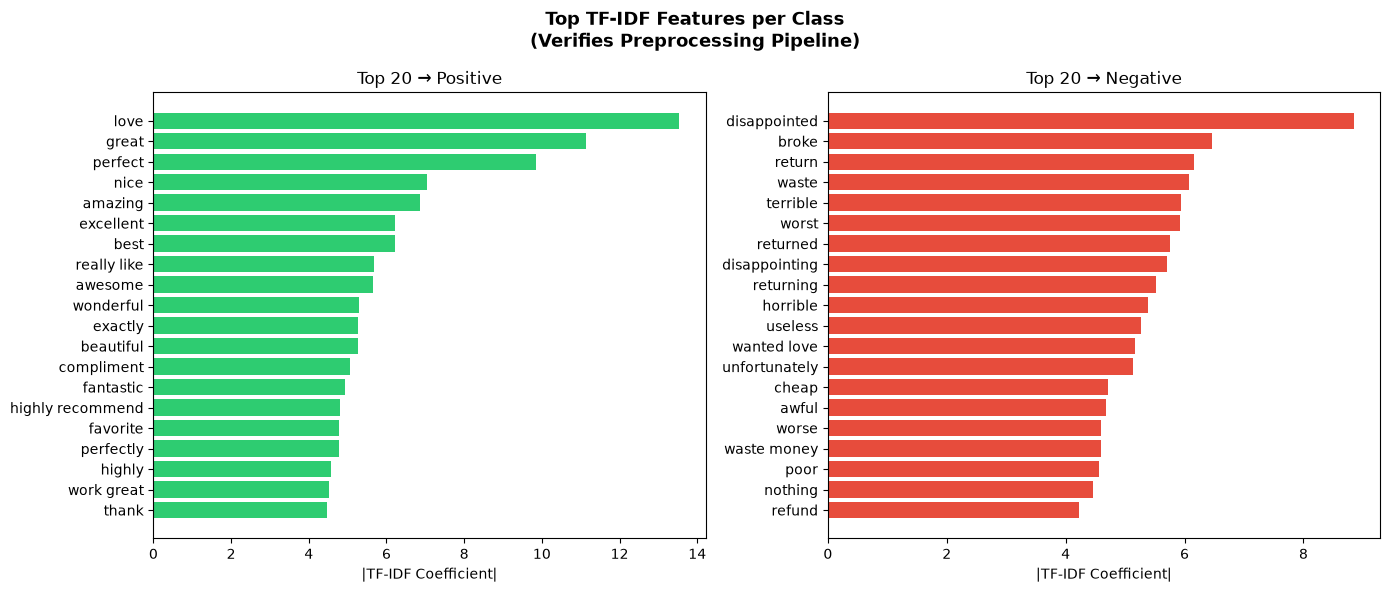

Pipeline check: do the features above make intuitive sense?
Positive top words should include: great, love, perfect, amazing ...
Negative top words should include: return, waste, broke, terrible ...


In [15]:
#cell 7

probe = LogisticRegression(max_iter=500, C=1.0, solver="lbfgs")
probe.fit(X_train_tfidf, y_train)
 
feature_names = np.array(vectorizer.get_feature_names_out())
coefs         = probe.coef_[0]
n             = 20
 
top_pos_idx = np.argsort(coefs)[-n:][::-1]
top_neg_idx = np.argsort(coefs)[:n]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Top TF-IDF Features per Class\n(Verifies Preprocessing Pipeline)", fontsize=13, fontweight="bold")
 
for ax, idx, title, color in [
    (axes[0], top_pos_idx, "Top 20 → Positive", "#2ecc71"),
    (axes[1], top_neg_idx, "Top 20 → Negative", "#e74c3c"),
]:
    ax.barh(feature_names[idx][::-1], np.abs(coefs[idx][::-1]), color=color)
    ax.set_title(title)
    ax.set_xlabel("|TF-IDF Coefficient|")
 
plt.tight_layout()
plt.show()
 
print("Pipeline check: do the features above make intuitive sense?")
print("Positive top words should include: great, love, perfect, amazing ...")
print("Negative top words should include: return, waste, broke, terrible ...")
 

In [28]:
#cell 8 training
import wandb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

wandb.finish()

run = wandb.init(
    entity="aiml2026",                     
    project="amazon-sentiment-analysis",   
    group="logreg",                        
    job_type="train",
    name="logistic-regression",
    tags=["logreg", "tfidf"],
    config={
        "model": "Logistic Regression",
        "C": 1.0,
        "max_iter": 1000,
        "solver": "lbfgs",
        "class_weight": "balanced",
        "tfidf_max_features": 15000,
        "ngram_range": "(1,2)",
        "train_samples": len(X_train_tfidf.toarray()), 
        "test_samples": len(X_test_tfidf.toarray()),
    }
)

print("Training Logistic Regression...")
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42,
)
lr_model.fit(X_train_tfidf, y_train)
print("Training complete!")

y_pred  = lr_model.predict(X_test_tfidf)
y_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]

print("\n--- MODEL PERFORMANCE (Test Set) ---")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

wandb.log({
    "test_accuracy": accuracy_score(y_test, y_pred),
    "test_precision": precision_score(y_test, y_pred),
    "test_recall": recall_score(y_test, y_pred),
    "test_f1": f1_score(y_test, y_pred),
    "test_roc_auc": roc_auc_score(y_test, y_proba)
})

wandb.finish()

Training Logistic Regression...


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Training complete!

--- MODEL PERFORMANCE (Test Set) ---
              precision    recall  f1-score   support

    Negative       0.87      0.89      0.88     12500
    Positive       0.89      0.87      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
test_roc_auc,▁
test_accuracy,0.88056
test_f1,0.87934
test_precision,0.88839
test_recall,0.87048
test_roc_auc,0.95149


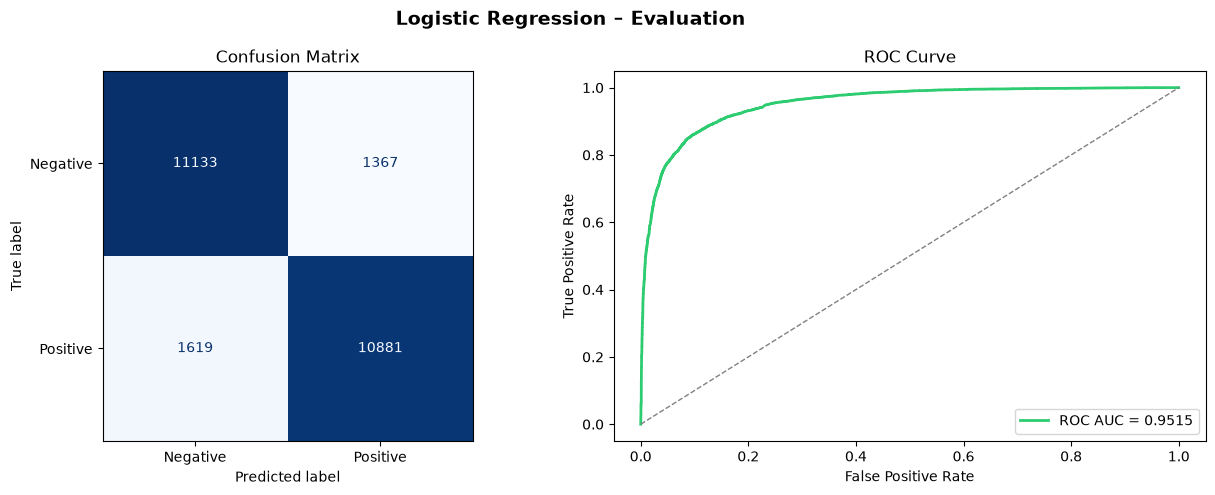

In [17]:
#cell 9

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Logistic Regression – Evaluation", fontsize=14, fontweight="bold")
 
#confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")
 
#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#2ecc71", lw=2, label=f"ROC AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")
 
plt.tight_layout()
plt.show()
 

In [1]:
import sys
!{sys.executable} -m pip install wandb

   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   -- ------------------------------------- 1.6/24.5 MB 8.0 MB/s eta 0:00:03
   ----- ---------------------------------- 3.7/24.5 MB 8.9 MB/s eta 0:00:03
   --------- ------------------------------ 6.0/24.5 MB 9.7 MB/s eta 0:00:02
   ------------- -------------------------- 8.4/24.5 MB 10.1 MB/s eta 0:00:02
   ----------------- ---------------------- 11.0/24.5 MB 10.4 MB/s eta 0:00:02
   --------------------- ------------------ 13.4/24.5 MB 10.6 MB/s eta 0:00:02
   ------------------------- -------------- 15.5/24.5 MB 10.6 MB/s eta 0:00:01
   ----------------------------- ---------- 18.1/24.5 MB 10.7 MB/s eta 0:00:01
   --------------------------------- ------ 20.4/24.5 MB 10.8 MB/s eta 0:00:01
   ------------------------------------- -- 22.8/24.5 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.5 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------- 24.5/24.5 MB 10.5 MB/s  

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import sys
!{sys.executable} -m wandb sync --sync-all

wandb: ERROR Nothing to sync.
